In [1]:
# Standard imports
import polars as pl
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration 
from IPython.display import display

# Polars display settings (default 10x8)
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(15)

# Matplotlib/Seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Path to data
DATA_PATH = Path("../data/raw/train.gz")

print(f"Polars version: {pl.__version__}")
print(f"Data file exists: {DATA_PATH.exists()}")


Polars version: 1.39.3
Data file exists: True


#### Counting rows

In [2]:
# Lazy scan - defines the plan, does not load the data yet
df_lazy = pl.scan_csv(
    DATA_PATH,
    schema_overrides={"id": pl.String} # id is too large for Int64
)

# Count total rows (forces computation)
total_rows = df_lazy.select(pl.len()).collect().item()

print(f"Total rows: {total_rows:,}")
print(f"Total rows (scientific): {total_rows:.2e}")

Total rows: 40,428,967
Total rows (scientific): 4.04e+07


## Baseline CTR

In [3]:
# Count clicks (sum of 1s) and non-clicks (count - sum)
click_stats = (
    df_lazy
    .select([
        pl.col("click").sum().alias("clicks"),
        pl.len().alias("total"),
    ])
    .collect()
)

display(click_stats)

# Extract values for calculations
n_clicks = click_stats["clicks"].item()
n_total = click_stats["total"].item()
n_no_clicks = n_total - n_clicks

# Calculate baseline CTR
baseline_ctr = n_clicks / n_total

print(f"\n{'Clicks:':<12} {n_clicks:>12,} ({baseline_ctr:.2%})")
print(f"{'No clicks:':<12} {n_no_clicks:>12,} ({1 - baseline_ctr:.2%})")
print(f"{'Total:':<12} {n_total:>12,}")
print(f"\n{'Baseline CTR:':<12} {baseline_ctr:.4f} ({baseline_ctr:.2%})")

clicks,total
i64,u32
6865066,40428967



Clicks:         6,865,066 (16.98%)
No clicks:     33,563,901 (83.02%)
Total:         40,428,967

Baseline CTR: 0.1698 (16.98%)


## Time distribution

In [4]:
# Extract date components from "hour" column (format: YYMMDDHH)
# 1. Cast to string -> 2. Extract substrings
time_distribution = (
    df_lazy
    .with_columns(
        pl.col("hour").cast(pl.String).alias("hour_str")
    )
    .with_columns([
        pl.col("hour_str").str.slice(0, 2).alias("year"),
        pl.col("hour_str").str.slice(2, 2).alias("month"),
        pl.col("hour_str").str.slice(4, 2).alias("day"),
        pl.col("hour_str").str.slice(6, 2).alias("hour_of_day"),
    ])
    .group_by("day")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks"),
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("day")
    .collect()
)

display(time_distribution)

day,impressions,clicks,ctr
str,u32,i64,f64
"""21""",4122995,718218,0.174198
"""22""",5337126,838820,0.157167
"""23""",3870752,705211,0.18219
"""24""",3335302,582730,0.174716
"""25""",3363122,613440,0.182402
"""26""",3835892,702156,0.183049
"""27""",3225010,585643,0.181594
"""28""",5287222,804622,0.152182
"""29""",3832608,600041,0.156562


- last 3 days with lower CTR  -> problem for validation? may not be that representative in comparison to previous days (used for training)

#### Hourly distribution

In [5]:
# CTR by hour of day (0-23), aggregated across all days
hourly_ctr = (
    df_lazy
    .with_columns(
        pl.col("hour").cast(pl.String).str.slice(6, 2).alias("hour_of_day")
    )
    .group_by("hour_of_day")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks"),
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("hour_of_day")
    .collect()
)

display(hourly_ctr)

hour_of_day,impressions,clicks,ctr
str,u32,i64,f64
"""00""",845178,152429,0.180351
"""01""",984784,182947,0.185774
"""02""",1222672,215322,0.176108
"""03""",1399001,243705,0.174199
"""04""",1913348,305308,0.159567
"""05""",1982179,323863,0.163387
"""06""",1762743,296346,0.168116
"""07""",1857712,332884,0.17919
"""08""",2096264,342120,0.163205


#### Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

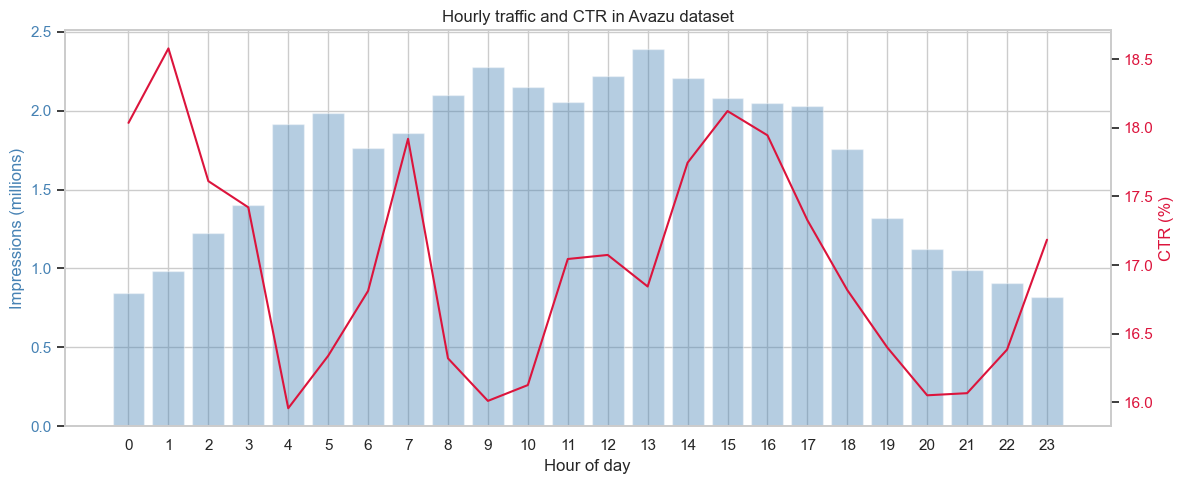

In [6]:
# Convert to Pandas for Matplotlib compatibility
hourly_pd = hourly_ctr.to_pandas()
hourly_pd["hour_of_day"] = hourly_pd["hour_of_day"].astype(int)
hourly_pd = hourly_pd.sort_values("hour_of_day")

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# Impressions as bars (left axis)
ax1.bar(hourly_pd["hour_of_day"], hourly_pd["impressions"] / 1e6, alpha=0.4, color="steelblue", label="Impressions")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Impressions (millions)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(0,24))

# CTR as line
ax2 = ax1.twinx()
ax2.plot(hourly_pd["hour_of_day"], hourly_pd["ctr"] * 100, color="crimson", label="CTR")
ax2.set_ylabel("CTR (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.grid(False)

plt.title("Hourly traffic and CTR in Avazu dataset")
plt.tight_layout()
plt.show


## Cardinality

In [7]:
# Count unique values for every column (full scan through 40M rows - expensive)
cardinality = (
    df_lazy
    .select([
        pl.col(c).n_unique().alias(c) for c in df_lazy.collect_schema().names()
    ])
    .collect()
)

# Transpose to have columns as rows (for readable display)
cardinality_long = (
    cardinality
    .transpose(include_header=True, header_name="column", column_names=["n_unique"])
    .sort("n_unique", descending=True)
)

display(cardinality_long)

column,n_unique
str,u32
"""id""",40428967
"""device_ip""",6729486
"""device_id""",2686408
"""app_id""",8552
"""device_model""",8251
"""site_domain""",7745
"""site_id""",4737
"""C14""",2626
"""app_domain""",559


#### Discussion - cardinality
- id - 100% unique values -> unique identifier, so it makes sense -> not useful for later
- device_ip > device_id -> WIFI/LTE/diffent internet providers? -> device_id may be better for analysing behavior of a specific user
- device_model -> 8k is quite high, but may be realistic
- hour -> 10 days * 24 hours = 240
- banner_pos -> 7 = little number of possibilities (easy for modeling?)

### Distribution of app vs site "traffic"
Each sample (row) corresponds to either "site" or "app" impression. The other one is then filled with a placeholder - it has to be checked what exactly is the value corresponding to a placeholder in both cases. They will be probably the most frequent values in both columns (site_id and app_id).

In [8]:
# Top 5 most frequent values in site_id and app_id
top_site = (
    df_lazy
    .group_by("site_id")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .limit(5)
    .collect()
)

top_app = (
    df_lazy
    .group_by("app_id")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .limit(5)
    .collect()
)

print("Top 5 site_id values:")
display(top_site)

print("Top 5 app_id values:")
display(top_app)

Top 5 site_id values:


site_id,count
str,u32
"""85f751fd""",14596137
"""1fbe01fe""",6486150
"""e151e245""",2637747
"""d9750ee7""",963745
"""5b08c53b""",913325


Top 5 app_id values:


app_id,count
str,u32
"""ecad2386""",25832830
"""92f5800b""",1555283
"""e2fcccd2""",1129016
"""febd1138""",759098
"""9c13b419""",757812


__Placeholder for site traffic__ -> ecad2386 as app_id

__Placeholder for app traffic__ -> 85f751fd as site_id

#### Does it make sense?
14596137 (site_id = "85f751fd") + 25832830 (app_id = "ecad2386") = 40428967 -> sums up to the total number of impressions

64% - site traffic
36% - app traffic

#### Flaging the placeholders

In [9]:
# Placeholder values identified above
SITE_PLACEHOLDER_IN_APP_ID = "ecad2386"
APP_PLACEHOLDER_IN_SITE_ID = "85f751fd"

# Add is_app flag and compute CTR per traffic type
traffic_type_ctr = (
    df_lazy
    .with_columns(
        # If app_id is NOT the placeholder, then it's app traffic
        (pl.col("app_id") != SITE_PLACEHOLDER_IN_APP_ID).alias("is_app")
    )
    .group_by("is_app") # grouping by the traffic type
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("is_app")
    .collect()
)

display(traffic_type_ctr)

is_app,impressions,clicks,ctr
bool,u32,i64,f64
false,25832830,5130659,0.19861
true,14596137,1734407,0.118826


Drastically different CTR depending on the traffic type.

#### Why?
- different intention of user when opening the site/app?
- ad placement more intrusive in apps?
- some technical issues with obtaining data for apps?

## CTR per banner position

In [10]:
banner_ctr = (
    df_lazy
    .group_by("banner_pos")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("banner_pos")
    .collect()
)

display(banner_ctr)

banner_pos,impressions,clicks,ctr
i64,u32,i64,f64
0,29109590,4781901,0.164272
1,11247282,2065164,0.183614
2,13001,1550,0.119222
3,2035,372,0.182801
4,7704,1428,0.185358
5,5778,702,0.121495
7,43577,13949,0.3201


## CTR per device_type and device_conn_type

In [11]:
# CTR by device_type
device_type_ctr = (
    df_lazy
    .group_by("device_type")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("device_type")
    .collect()
)

# CTR by device_conn_type
device_conn_type_ctr = (
    df_lazy
    .group_by("device_conn_type")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("device_conn_type")
    .collect()
)
print("CTR by device_type:")
display(device_type_ctr)

print("\nCTR by device_conn_type:")
display(device_conn_type_ctr)

CTR by device_type:


device_type,impressions,clicks,ctr
i64,u32,i64,f64
0,2220812,467995,0.210731
1,37304667,6311046,0.169176
2,31,2,0.064516
4,774272,73900,0.095444
5,129185,12123,0.093842



CTR by device_conn_type:


device_conn_type,impressions,clicks,ctr
i64,u32,i64,f64
0,34886838,6318889,0.181125
2,3317443,448815,0.135289
3,2181796,96092,0.044043
5,42890,1270,0.029611


#### CTR by device_type
- "1" is probably a smartphone (overwhelmingly high number)
- "0" a tablet? (higher CTR caused by bigger ads?)
#### CTR by device_conn_type
- "0" dominates the number of impressions (WIFI?) and posseses the highest CTR 

#### Good features - strong predictors
- high differences between categories for both features -> high value for predictions
- low cardinality -> easy for modeling

## CTR per app/site category

In [12]:
# App categories (only for app traffic)
app_category_ctr = (
    df_lazy
    .filter(pl.col("app_id") != SITE_PLACEHOLDER_IN_APP_ID)
    .group_by("app_category")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("impressions", descending=True)
    .limit(10)
    .collect()
)

# Site categories (only site app traffic)
site_category_ctr = (
    df_lazy
    .filter(pl.col("app_id") == SITE_PLACEHOLDER_IN_APP_ID)
    .group_by("site_category")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns(
        (pl.col("clicks") / pl.col("impressions")).alias("ctr")
    )
    .sort("impressions", descending=True)
    .limit(10)
    .collect()
)

print("CTR per app category:")
display(app_category_ctr)

print("\nCTR per site category:")
display(site_category_ctr)

CTR per app category:


app_category,impressions,clicks,ctr
str,u32,i64,f64
"""0f2161f8""",9561058,1033720,0.108118
"""cef3e649""",1731545,161450,0.09324
"""8ded1f7a""",1467257,132021,0.089978
"""f95efa07""",1141673,282664,0.247588
"""07d7df22""",332762,80163,0.240902
"""d1327cf5""",123233,15197,0.123319
"""09481d60""",54886,8518,0.155194
"""dc97ec06""",54644,8552,0.156504
"""75d80bbe""",40108,3849,0.095966



CTR per site category:


site_category,impressions,clicks,ctr
str,u32,i64,f64
"""f028772b""",12657073,2272940,0.179579
"""28905ebd""",7377208,1534600,0.208019
"""3e814130""",3050306,863245,0.283003
"""50e219e0""",1941097,391943,0.201918
"""f66779e6""",252451,10019,0.039687
"""75fa27f6""",160985,17915,0.111284
"""335d28a8""",136463,12779,0.093644
"""76b2941d""",104754,3170,0.030261
"""c0dd3be3""",42090,4714,0.111998


#### CTR per app
- 0f2161f8 is dominating (66%) - some social media app?
- 2 categories with CTR=24% - 2x the CTR for 0f2161f8
#### CTR per site
- f028772b is dominating (49%) - some news site?
- varied CTR even for relevant categories
- high CTR - well matched adds for the type of site?

#### Conclusions
- both features are valuable
- low cardinality - easy for modelling
- deviding categories into separate app and site categories - good idea (averaged CTR without it)

## Conversion to Parquet

In [13]:
# Paths
RAW_PATH = Path("../data/raw/train.gz")
PARQUET_PATH = Path("../data/interim/train.parquet")

# Make sure interim directory exists
PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)

# Check if already converted
if PARQUET_PATH.exists():
    print(f"Parquet already exists: {PARQUET_PATH}")
    print(f"Size: {PARQUET_PATH.stat().st_size / 1e9:.2f} GB")
else:
    print("Converting CSV.gz to Parquet...")

    # Define schema explicitly to avoid type inference issues
    schema_overrides = {
        "id": pl.String,
        "click": pl.Int8, # smaller type - values are 0 or 1
        "hour": pl.Int64,
        "C1": pl.Int32,
        "banner_pos": pl.Int8,
        "device_type": pl.Int8,
        "device_conn_type": pl.Int8,
        "C14": pl.Int32,
        "C15": pl.Int16,
        "C16": pl.Int16,
        "C17": pl.Int32,
        "C18": pl.Int8,
        "C19": pl.Int16,
        "C20": pl.Int32,
        "C21": pl.Int16
    }

    # Read full CSV (one-time cost) and write as Parquet
    df = pl.read_csv(RAW_PATH, schema_overrides=schema_overrides)

    print(f"Rows loaded: {df.height:,}")
    print(f"Memory usage: {df.estimated_size() / 1e9:.2f} GB")

    # Write with zstd compression - best comprise of size and speed
    df.write_parquet(PARQUET_PATH, compression="zstd")

    print(f"\nParquet written: {PARQUET_PATH}")
    print(f"Size: {PARQUET_PATH.stat().st_size / 1e9:.2f} GB")

Parquet already exists: ..\data\interim\train.parquet
Size: 1.00 GB


In [14]:
# Switch to Parquet for remaining analyses (much faster)
df_lazy = pl.scan_parquet(PARQUET_PATH)

# Quick sanity check
print(f"Total rows (from Parquet): {df_lazy.select(pl.len()).collect().item():,}")

Total rows (from Parquet): 40,428,967


## "C" columns

In [15]:
# CTR for low-cardinality C columns
for col in ["C1","C15","C16","C18"]:
    result = (
        df_lazy
        .group_by(col)
        .agg([
            pl.len().alias("impressions"),
            pl.col("click").sum().alias("clicks")
        ])
        .with_columns(
            (pl.col("clicks") / pl.col("impressions")).alias("ctr")
        )
        .sort("impressions", descending=True)
        .collect()
    )

    print(f"\n=== {col} ===")
    display(result)


=== C1 ===


C1,impressions,clicks,ctr
i32,u32,i64,f64
1005,37140632,6289056,0.169331
1002,2220812,467995,0.210731
1010,903457,86023,0.095215
1012,113512,19580,0.172493
1007,35304,1392,0.039429
1001,9463,316,0.033393
1008,5787,704,0.121652



=== C15 ===


C15,impressions,clicks,ctr
i16,u32,i64,f64
320,37708959,5980935,0.158608
300,2337294,839925,0.359358
216,298794,37988,0.127138
728,74533,4246,0.056968
120,3069,58,0.018899
1024,2560,652,0.2546875
480,2137,572,0.267665
768,1621,690,0.425663



=== C16 ===


C16,impressions,clicks,ctr
i16,u32,i64,f64
50,38136554,6037589,0.158315
250,1806334,761093,0.421347
36,298794,37988,0.127138
480,103365,22178,0.21456
90,74533,4246,0.056968
20,3069,58,0.018899
768,2560,652,0.2546875
320,2137,572,0.267665
1024,1621,690,0.425663



=== C18 ===


C18,impressions,clicks,ctr
i8,u32,i64,f64
0,16939044,2680172,0.158225
3,13654242,1992882,0.145953
2,7116058,2099065,0.294976
1,2719623,92947,0.034176


##### Conclusions - strong predictors
- C1 -> the same distribution as device_type (above) --> reduntant
- C15 and C16 seem to be connected - the similar impressions, clicks and CTR values in both categories for some cases
- C18 high variability - very different values of CTR

In [16]:
# Evaluate predictive power of high-cardinality C columns (too many different values for the analogous analysis to the one above)
high_card_cols = ["C14","C17","C19","C20","C21"]

results = []

for col in high_card_cols:
    # CTR per category
    agg = (
        df_lazy
        .group_by(col)
        .agg([
            pl.len().alias("n"),
            pl.col("click").sum().alias("clicks")
        ])
        .with_columns(
            (pl.col("clicks") / pl.col("n")).alias("ctr")
        )
        .collect()
    )

    # Filter out rare categories (< 1000 impressions) to avoid noise
    agg_filtered = agg.filter(pl.col("n") >= 1000)

    # Weigthed standard deviation of CTR
    total_n = agg_filtered["n"].sum()
    weighted_mean = (agg_filtered["ctr"] * agg_filtered["n"]).sum() / total_n
    weighted_var = ((agg_filtered["ctr"])**2 * agg_filtered["n"]).sum() / total_n
    weighted_std = weighted_var ** 0.5

    results.append({
        "column": col,
        "n_unique": agg.height,
        "n_unique_freq": agg_filtered.height, # with >= 1000 impressions
        "ctr_mean": weighted_mean,
        "ctr_std": weighted_std,
        "ctr_min": agg_filtered["ctr"].min(),
        "ctr_max": agg_filtered["ctr"].max()
    })

# Display as DataFrame
results_df = pl.DataFrame(results).sort("ctr_std", descending=True)
display(results_df)
    

column,n_unique,n_unique_freq,ctr_mean,ctr_std,ctr_min,ctr_max
str,i64,i64,f64,f64,f64,f64
"""C14""",2626,1303,0.169961,0.197607,0.0,0.731487
"""C17""",435,376,0.169823,0.196114,0.002473,0.72129
"""C21""",60,59,0.169806,0.185963,0.028201,0.393919
"""C19""",68,62,0.169807,0.18208,0.023174,0.474116
"""C20""",172,146,0.169813,0.176774,0.022281,0.306373


- high variablity of all features (std quite high)
- std of C14 and C17 the highest (also the biggest range of CTR values) --> might be the best predictors here
- all possibly useful for the model

# Correlations between C values

### Is C1 the same infromation as device_type?

In [19]:
# Check correlation between C1 and device_type
c1_devtype = (
    df_lazy
    .group_by(["C1", "device_type"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

print(f"Number of unique (C1, device_type) pairs: {c1_devtype.height}")
print(f"Number of unique device_type values: 5")
print(f"Number of unique C1 values: 7 \n")

display(c1_devtype)

Number of unique (C1, device_type) pairs: 9
Number of unique device_type values: 5
Number of unique C1 values: 7 



C1,device_type,count
i32,i8,u32
1005,1,37140632
1002,0,2220812
1010,4,774272
1010,5,129185
1012,1,113481
1007,1,35304
1001,1,9463
1008,1,5787
1012,2,31


- 7 pairs --> identical
- 35 pairs --> totally unrelated (but >20 might also suggest unrelated values)

__Our result:__
 - 9 pairs - C1 and device_type are not identical but strongly correlated (something similar? maybe C1 is a subcategory of device_type?)
 - C1 is not completely redundant

### Are C15 and C16 related? 

In [27]:
# Check correlation between C15 and C16
c15_c16 = (
    df_lazy
    .group_by(["C15", "C16"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

n_c15 = df_lazy.select(pl.col("C15").n_unique()).collect().item()
n_c16 = df_lazy.select(pl.col("C16").n_unique()).collect().item()

print(f"C15: {n_c15} unique values")
print(f"C16: {n_c16} unique values")
print(f"Maximum possible combinations: {n_c15 * n_c16}")
print(f"Actual combinations: {c15_16.height}\n")

display(c15_c16)

C15: 8 unique values
C16: 9 unique values
Maximum possible combinations: 72
Actual combinations: 10



C15,C16,count
i16,i16,u32
320,50,37605594
300,250,1806334
300,50,530960
216,36,298794
320,480,103365
728,90,74533
120,20,3069
1024,768,2560
480,320,2137


#### Conclusions
- C15 and C16 are almost related 1-to-1
- strongly correlated but not identical - neither is redundant

### Are C14 and C17 related?

In [33]:
# Check correlation between C14 and C17
c14_c17 = (
    df_lazy
    .group_by(["C14","C17"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

n_c14 = df_lazy.select(pl.col("C14").n_unique()).collect().item()
n_c17 = df_lazy.select(pl.col("C17").n_unique()).collect().item()

print(f"C14: {n_c14} unique values")
print(f"C17: {n_c17} unique values")
print(f"Maximum possible combinations: {n_c14 * n_c17}")
print(f"Actual combinations: {c14_c17.height}")
print(f"Ratio to max: {c14_c17.height / (n_c14 * n_c17):.4f}")
print(f"Ratio to max(n_c14, n_c17): {(c14_c17.height) / max(n_c14, n_c17):.2f}")

C14: 2626 unique values
C17: 435 unique values
Maximum possible combinations: 1142310
Actual combinations: 2626
Ratio to max: 0.0023
Ratio to max(n_c14, n_c17): 1.00


- C14 is a subcategory of C17? or C14 is a group in C17?
- C14 has higher cardinality and more values overall - probably more informative for the model

## Splitting data into training and validation sets

In [38]:
# Define split boundaries
# Dataset covers days 21-30.10.2014 (hour column format: YYMMDDHH)

TRAIN_DAYS = ["21","22","23","24","25","26","27","28"]
VAL_DAYS = ["29","30"]

# Extract day from hour columns and create a label
split_labels = (
    df_lazy
    .with_columns(
        pl.col("hour").cast(pl.String).str.slice(4,2).alias("day")
    )
    .with_columns(
        pl.when(pl.col("day").is_in(TRAIN_DAYS))
        .then(pl.lit("train"))
        .when(pl.col("day").is_in(VAL_DAYS))
        .then(pl.lit("val"))
        .otherwise(pl.lit("uknown")) # just to be safe
        .alias("split")
    )
)

# Verify split - count rows and compute CTR per split
split_summary = (
    split_labels
    .group_by("split")
    .agg([
        pl.len().alias("impressions"),
        pl.col("click").sum().alias("clicks")
    ])
    .with_columns([
        (pl.col("clicks") / pl.col("impressions")).alias("ctr"),
        (pl.col("impressions") / pl.col("impressions").sum()).alias("share")
    ])
    .sort("split")
    .collect()
)

display(split_summary)

split,impressions,clicks,ctr,share
str,u32,i64,f64,f64
"""train""",32377421,5550840,0.171442,0.800847
"""val""",8051546,1314226,0.163227,0.199153


In [40]:
# Save train and val as separate parquet files
TRAIN_PATH = Path("../data/interim/train_split.parquet")
VAL_PATH = Path("../data/interim/val_split.parquet")

#Save train split (days 21-28)
print("Saving train split...")
(
    split_labels
    .filter(pl.col("split") == "train")
    .drop(["day", "split"]) # helper columns not needed
    .collect()
    .write_parquet(TRAIN_PATH, compression="zstd")
)
print(f"Train saved at: {TRAIN_PATH}")
print(f"Train size: {TRAIN_PATH.stat().st_size / 1e9:.2f} GB")

# Save val split (days 29-30)
print("Saving validation split...")
(
    split_labels
    .filter(pl.col("split") == "val")
    .drop(["day", "split"])
    .collect()
    .write_parquet(VAL_PATH, compression="zstd")
)

print(f"Val saved at: {VAL_PATH}")
print(f"Val size: {VAL_PATH.stat().st_size / 1e9:.2f} GB")

Saving train split...
Train saved at: ..\data\interim\train_split.parquet
Train size: 0.80 GB
Saving validation split...
Val saved at: ..\data\interim\val_split.parquet
Val size: 0.20 GB


In [42]:
# Quick verification - load splits as lazy frames and check size/CTR
train_lazy = pl.scan_parquet(TRAIN_PATH)
val_lazy = pl.scan_parquet(VAL_PATH)

train_stats = (
    train_lazy
    .select([
        pl.len().alias("rows"),
        pl.col("click").mean().alias("ctr") # click values between 0 and 1 --> mean corresponds to CTR
    ])
    .collect()
)

val_stats = (
    val_lazy
    .select([
        pl.len().alias("rows"),
        pl.col("click").mean().alias("ctr")
    ])
    .collect()
)

print(f"Train: {train_stats['rows'].item():,} rows, CTR = {train_stats['ctr'].item():.4f}")
print(f"Val: {val_stats['rows'].item():,} rows, CTR = {val_stats['ctr'].item():.4}")

Train: 32,377,421 rows, CTR = 0.1714
Val: 8,051,546 rows, CTR = 0.1632


# EDA summary

### Size and structure
- 40.4M rows
- 10 days (21-30.10.2014)
- 17% baseline CTR (very high)
- circadian pattern in traffic and CTR (CTR higher at night)

### Traffic
- 64% site and 36% app traffic
- higher CTR for site

### Features
- strong: device_conn_type, banner_pos, device_type, app/site categories, C14, C17, C15/C16
- weak: id (all unique)
- redundant: C1 (duplicate of device_type information), C14 (subset of C17)

### Cardinality
- very high (millions): id, device_ip, device_id
- high (thousands): app_id, device_model, site_domain, site_id, C14
- low (<100): most columns (banner, device_type, various "C" columns)

### Split for modeling
- train: days 21-28 (32.4M rows, CTR=17.14%)
- val: days 29-30 (8.1M rows, CTR=16.32%)
- data drift between sets (visibly higher CTR in the train split)